In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor, Lasso, ElasticNet, BayesianRidge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


In [122]:
# Load data with all features from Module 1
df = pd.read_csv('data_processed_module1.csv')

print("Data loaded")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Data loaded
Shape: (57, 49)
Columns: ['Week', 'FB_Spend', 'GG_Spend', 'Seasonality', 'Promo', 'FB_Adstock', 'GG_Adstock', 'FB_Effect', 'GG_Effect', 'Traffic', 'Sales', 'Clicks', 'Conversions', 'CPC', 'CR', 'ROAS', 'ROI', 'FB_GG_Ratio', 'GG_FB_Ratio', 'Total_Spend', 'FB_Share', 'GG_Share', 'Sales_per_Spend', 'Clicks_per_Spend', 'FB_Spend_lag1', 'GG_Spend_lag1', 'Total_Spend_lag1', 'Sales_lag1', 'CPC_lag1', 'FB_Spend_lag2', 'GG_Spend_lag2', 'Sales_lag2', 'FB_Spend_roll4', 'GG_Spend_roll4', 'Total_Spend_roll4', 'Sales_roll4', 'CPC_roll4', 'FB_Spend_sum4', 'GG_Spend_sum4', 'Total_Spend_sum4', 'FB_Spend_std4', 'GG_Spend_std4', 'FB_Promo', 'GG_Promo', 'Total_Spend_Promo', 'FB_Season', 'GG_Season', 'Total_Spend_Season', 'FB_GG_Interaction']

First 3 rows:
        Week     FB_Spend     GG_Spend  Seasonality  Promo    FB_Adstock  \
0  1/28/2024  5591.950905  5497.273287     1.092218      0  11244.909280   
1   2/4/2024  2936.111843  4966.541568     1.119273      0   8558.566482   
2  2/11/2024 

CORRELATION WITH SALES
 Sales: 1.0000 (target)
   Traffic: 0.4641 →  Medium
   GG_Spend: 0.4026 →  Medium
   Promo: 0.3940 →  Medium
   Seasonality: 0.3512 →  Medium
   FB_Spend: 0.1944 →  Weak

FULL CORRELATION MATRIX
             FB_Spend  GG_Spend  Traffic  Sales  Promo  Seasonality
FB_Spend        1.000    -0.008    0.280  0.194  0.017        0.110
GG_Spend       -0.008     1.000    0.753  0.403 -0.120       -0.021
Traffic         0.280     0.753    1.000  0.464 -0.251       -0.022
Sales           0.194     0.403    0.464  1.000  0.394        0.351
Promo           0.017    -0.120   -0.251  0.394  1.000       -0.059
Seasonality     0.110    -0.021   -0.022  0.351 -0.059        1.000


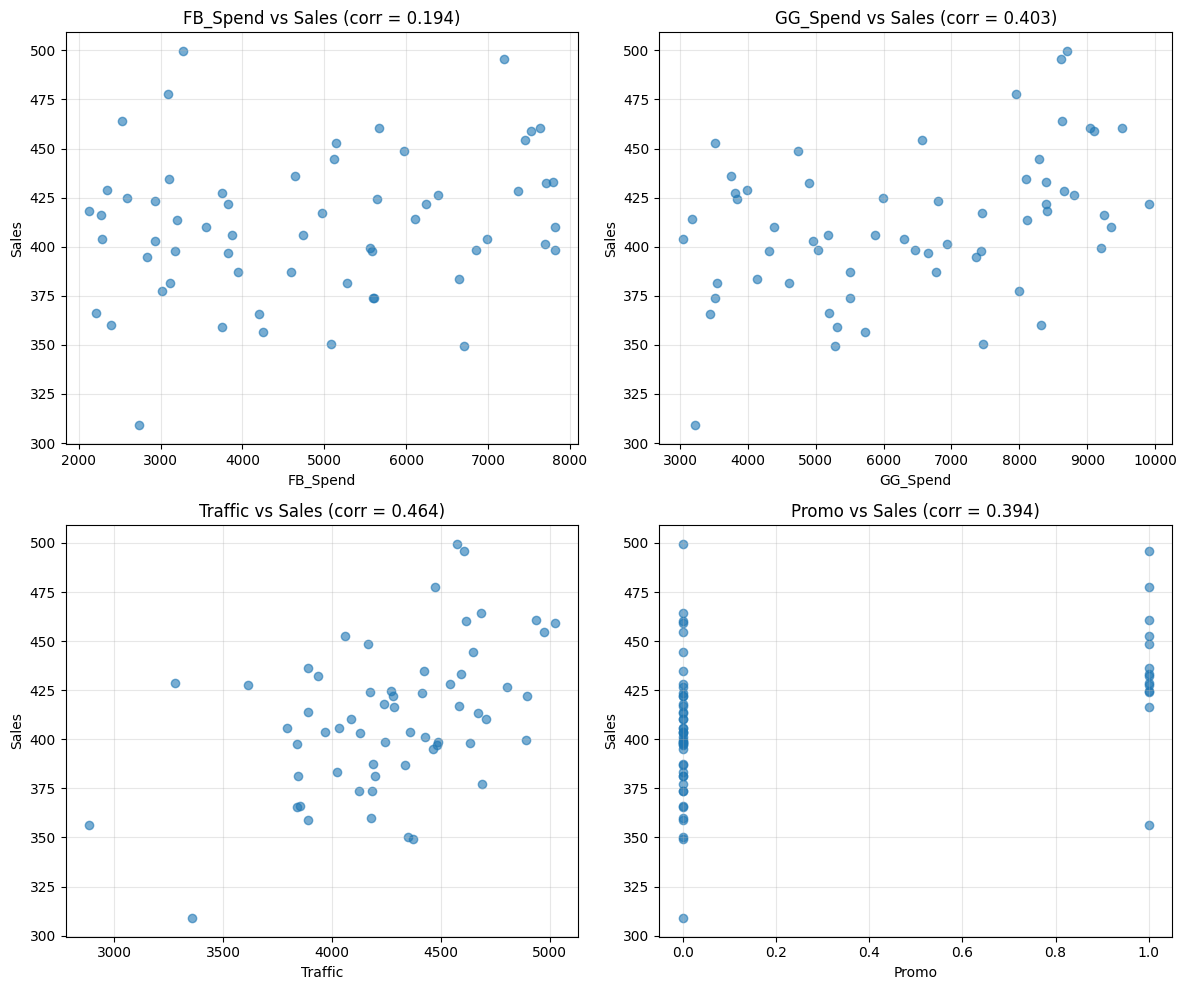


Conclusion
 It is recommended to use the following in the model: Variables with a correlation greater than 0.3 with Sales
 Variables with a correlation of less than 0.3 with Sales should not be used.


In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('marketing_dataset_sample.csv')

numeric_cols = ['FB_Spend', 'GG_Spend', 'Traffic', 'Sales', 'Promo', 'Seasonality']
df_numeric = df[numeric_cols]

correlations = df_numeric.corr()['Sales'].sort_values(ascending=False)

print("="*50)
print("CORRELATION WITH SALES")
print("="*50)
for col, corr in correlations.items():
    if col == 'Sales':
        print(f" {col}: {corr:.4f} (target)")
    else:
        # Đánh giá mức độ
        if abs(corr) > 0.7:
            level = " Very strong"
        elif abs(corr) > 0.5:
            level = " Strong"
        elif abs(corr) > 0.3:
            level = " Medium"
        elif abs(corr) > 0.1:
            level = " Weak"
        else:
            level = " Very weak / Null"
        
        print(f"   {col}: {corr:.4f} → {level}")

print("\n" + "="*50)
print("FULL CORRELATION MATRIX")
print("="*50)
print(df_numeric.corr().round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter: FB_Spend vs Sales
axes[0, 0].scatter(df['FB_Spend'], df['Sales'], alpha=0.6)
axes[0, 0].set_xlabel('FB_Spend')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].set_title(f'FB_Spend vs Sales (corr = {correlations["FB_Spend"]:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# Scatter: GG_Spend vs Sales
axes[0, 1].scatter(df['GG_Spend'], df['Sales'], alpha=0.6)
axes[0, 1].set_xlabel('GG_Spend')
axes[0, 1].set_ylabel('Sales')
axes[0, 1].set_title(f'GG_Spend vs Sales (corr = {correlations["GG_Spend"]:.3f})')
axes[0, 1].grid(True, alpha=0.3)

# Scatter: Traffic vs Sales
axes[1, 0].scatter(df['Traffic'], df['Sales'], alpha=0.6)
axes[1, 0].set_xlabel('Traffic')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].set_title(f'Traffic vs Sales (corr = {correlations["Traffic"]:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# Scatter: Promo vs Sales
axes[1, 1].scatter(df['Promo'], df['Sales'], alpha=0.6)
axes[1, 1].set_xlabel('Promo')
axes[1, 1].set_ylabel('Sales')
axes[1, 1].set_title(f'Promo vs Sales (corr = {correlations["Promo"]:.3f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Conclusion")
print("="*50)
print(" It is recommended to use the following in the model: Variables with a correlation greater than 0.3 with Sales")
print(" Variables with a correlation of less than 0.3 with Sales should not be used.")

traffic_corr = correlations['Traffic']
if abs(traffic_corr) < 0.3:
    print(f"\n Traffic has a correlation = {traffic_corr:.3f} with Sales (< 0.3)")
    print(" → This is why the two-tier model (Spend→Traffic→Sales) is wrong!")

In [124]:
print("="*60)
print("DATA PREPARATION - NO LEAKAGE")
print("="*60)

# Define target
target_col = 'Sales'

# Features to EXCLUDE (to prevent data leakage)
exclude_cols = [
    'Sales', 'Week', 'Year_Week', 'Sales_Predicted', 'Error', 'Error_Pct',
    'Sales_lag1', 'Sales_lag2', 'Sales_roll4',
    'Sales_per_Spend', 'ROAS', 'ROI', 'CR', 'CPC'
]

# Define all features
all_features = [col for col in df.columns if col not in exclude_cols]

# Separate features: numeric vs binary
numeric_features = [col for col in all_features if col not in ['Promo', 'Promo_Fake']]
binary_features = ['Promo'] if 'Promo' in all_features else []
binary_features = [col for col in binary_features if col in all_features]

print(f"Numeric features (will scale): {len(numeric_features)}")
print(f"Binary features (no scale): {len(binary_features)}")
print(f"Total features: {len(numeric_features) + len(binary_features)}")

# Train/Test split
test_size = 6
train_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]

# Prepare train data
X_train_numeric = train_df[numeric_features].values
y_train = train_df[target_col].values

# Prepare test data
X_test_numeric = test_df[numeric_features].values
y_test = test_df[target_col].values

# Handle binary features if they exist
if binary_features:
    X_train_binary = train_df[binary_features].values
    X_test_binary = test_df[binary_features].values
else:
    X_train_binary = np.array([]).reshape(len(train_df), 0)
    X_test_binary = np.array([]).reshape(len(test_df), 0)

# Scale ONLY numeric features
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# Combine numeric + binary
if binary_features:
    X_train = np.hstack([X_train_numeric_scaled, X_train_binary])
    X_test = np.hstack([X_test_numeric_scaled, X_test_binary])
else:
    X_train = X_train_numeric_scaled
    X_test = X_test_numeric_scaled

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Train weeks: {len(train_df)}")
print(f"Test weeks: {len(test_df)}")

# Save
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(numeric_features, 'numeric_features.pkl')
joblib.dump(binary_features, 'binary_features.pkl')
print("\nSaved: scaler.pkl, numeric_features.pkl, binary_features.pkl")

DATA PREPARATION - NO LEAKAGE
Numeric features (will scale): 10
Binary features (no scale): 1
Total features: 11

X_train shape: (54, 11)
X_test shape: (6, 11)
Train weeks: 54
Test weeks: 6

Saved: scaler.pkl, numeric_features.pkl, binary_features.pkl


In [125]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Evaluate model with multiple metrics"""
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
    
    # TimeSeries CV score
    if len(X_train) >= 12:
        tscv = TimeSeriesSplit(n_splits=min(4, len(X_train)//3))
        cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    else:
        cv_mean = np.nan
        cv_std = np.nan
    
    return {
        'Model': model_name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_MAPE': test_mape,
        'CV_R2_mean': cv_mean,
        'CV_R2_std': cv_std,
        'Model_obj': model
    }

print("Evaluation function defined with MAE")

Evaluation function defined with MAE


In [126]:

print("="*60)
print("MODEL DEFINITION")
print("="*60)

models = {
    # Linear models
    'LinearRegression': LinearRegression(),
    
    # Ridge (different alphas)
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=0.5)': Ridge(alpha=0.5),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=5.0)': Ridge(alpha=5.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    
    # Huber (robust to outliers)
    'Huber (epsilon=1.35)': HuberRegressor(epsilon=1.35, alpha=0.5),
    'Huber (epsilon=1.5)': HuberRegressor(epsilon=1.5, alpha=0.5),
    'Huber (epsilon=2.0)': HuberRegressor(epsilon=2.0, alpha=0.5),
    
    # Bayesian Ridge (good for small data)
    'BayesianRidge': BayesianRidge(),
    
    # ElasticNet (L1 + L2)
    'ElasticNet (l1=0.5)': ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=1000),
    'ElasticNet (l1=0.8)': ElasticNet(alpha=0.5, l1_ratio=0.8, max_iter=1000),
    
    # Lasso (feature selection)
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=1000),
    'Lasso (alpha=0.5)': Lasso(alpha=0.5, max_iter=1000),
}

print(f"Total models to compare: {len(models)}")
for name in models.keys():
    print(f"  - {name}")

MODEL DEFINITION
Total models to compare: 14
  - LinearRegression
  - Ridge (alpha=0.1)
  - Ridge (alpha=0.5)
  - Ridge (alpha=1.0)
  - Ridge (alpha=5.0)
  - Ridge (alpha=10.0)
  - Huber (epsilon=1.35)
  - Huber (epsilon=1.5)
  - Huber (epsilon=2.0)
  - BayesianRidge
  - ElasticNet (l1=0.5)
  - ElasticNet (l1=0.8)
  - Lasso (alpha=0.1)
  - Lasso (alpha=0.5)


In [127]:
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS (Sorted by Test R²)")
print("="*70)
print(results_df[['Model', 'Test_R2', 'Test_MAE', 'Test_MAPE', 'Train_R2', 'CV_R2_mean']].head(10).to_string(index=False))


MODEL COMPARISON RESULTS (Sorted by Test R²)
               Model  Test_R2  Test_MAE  Test_MAPE  Train_R2  CV_R2_mean
 ElasticNet (l1=0.5) 0.134980 25.239968   5.859203  0.534262    0.408753
  Ridge (alpha=10.0) 0.113139 25.682593   5.977347  0.548883    0.372024
 ElasticNet (l1=0.8) 0.086296 26.123359   6.091734  0.557192    0.378781
 Huber (epsilon=2.0) 0.074994 25.932456   6.015114  0.541372    0.354428
   Ridge (alpha=5.0) 0.071727 26.311887   6.143564  0.561402    0.405910
       BayesianRidge 0.049257 26.594913   6.218264  0.564635    0.337896
 Huber (epsilon=1.5) 0.038056 26.447420   6.136901  0.537990    0.378101
Huber (epsilon=1.35) 0.031174 26.537254   6.156679  0.532496    0.367522
   Lasso (alpha=0.5) 0.024710 26.902747   6.296641  0.566034    0.217256
   Ridge (alpha=1.0) 0.020373 26.921783   6.304494  0.566569    0.300140


In [128]:
print("="*60)
print("BEST MODEL SELECTION")
print("="*60)

best_result = results_df.iloc[0]
best_model = best_result['Model_obj']
best_name = best_result['Model']

print(f"Best model: {best_name}")
print(f"Test R²: {best_result['Test_R2']:.4f}")
print(f"Test MAPE: {best_result['Test_MAPE']:.2f}%")
print(f"Train R²: {best_result['Train_R2']:.4f}")
print(f"CV R² mean: {best_result['CV_R2_mean']:.4f}")

# Check for overfitting
r2_gap = best_result['Train_R2'] - best_result['Test_R2']
if r2_gap > 0.3:
    print(f"\nWarning: Possible overfitting (Train R² - Test R² = {r2_gap:.4f})")
else:
    print(f"\nGood: No severe overfitting detected (gap = {r2_gap:.4f})")

print("\n" + "="*60)
print("MODULE 2 - COMPLETED")
print("="*60)
print(f"Best model: {best_name}")
print(f"Test R²: {best_result['Test_R2']:.4f}")
print(f"Test MAPE: {best_result['Test_MAPE']:.2f}%")

BEST MODEL SELECTION
Best model: ElasticNet (l1=0.5)
Test R²: 0.1350
Test MAPE: 5.86%
Train R²: 0.5343
CV R² mean: 0.4088


MODULE 2 - COMPLETED
Best model: ElasticNet (l1=0.5)
Test R²: 0.1350
Test MAPE: 5.86%


In [129]:
print("="*60)
print("TIMESERIES CROSS-VALIDATION DETAILS")
print("="*60)

tscv = TimeSeriesSplit(n_splits=min(4, len(X_train)//3))
cv_fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    # y_train is numpy array, use array indexing instead of .iloc
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    best_model.fit(X_fold_train, y_fold_train)
    pred = best_model.predict(X_fold_val)
    
    r2 = r2_score(y_fold_val, pred)
    mae = mean_absolute_error(y_fold_val, pred)
    
    cv_fold_results.append({'Fold': fold+1, 'R²': r2, 'MAE': mae})
    print(f"Fold {fold+1}: R² = {r2:.4f}, MAE = {mae:.2f}")

cv_df = pd.DataFrame(cv_fold_results)
print(f"\nMean R²: {cv_df['R²'].mean():.4f} (+/- {cv_df['R²'].std():.4f})")
print(f"Mean MAE: {cv_df['MAE'].mean():.2f}")

TIMESERIES CROSS-VALIDATION DETAILS
Fold 1: R² = 0.9696, MAE = 5.79
Fold 2: R² = 0.8861, MAE = 7.33
Fold 3: R² = 0.9536, MAE = 6.31
Fold 4: R² = 0.9516, MAE = 5.51

Mean R²: 0.9402 (+/- 0.0370)
Mean MAE: 6.23


In [130]:
print("="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# Predict on test set
y_test_pred = best_model.predict(X_test)

# Calculate metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test MAPE: {test_mape:.2f}%")

# Compare actual vs predicted (y_test is numpy array, no .values needed)
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Error': y_test - y_test_pred,
    'Error_Pct': (y_test - y_test_pred) / y_test * 100
})

print("\nTest set predictions (last 6 weeks):")
print(comparison.to_string(index=False))

# Save test predictions
comparison.to_csv('test_predictions.csv', index=False)
print("\nSaved: test_predictions.csv")

FINAL EVALUATION ON TEST SET
Test R²: 0.9531
Test MAE: 5.66
Test MAPE: 1.34%

Test set predictions (last 6 weeks):
    Actual  Predicted      Error  Error_Pct
397.982361 408.022895 -10.040534  -2.522859
459.089010 455.100842   3.988168   0.868713
464.095667 453.929192  10.166475   2.190599
397.662410 396.429591   1.232818   0.310016
416.390038 419.566941  -3.176903  -0.762963
387.073637 392.406940  -5.333304  -1.377852

Saved: test_predictions.csv


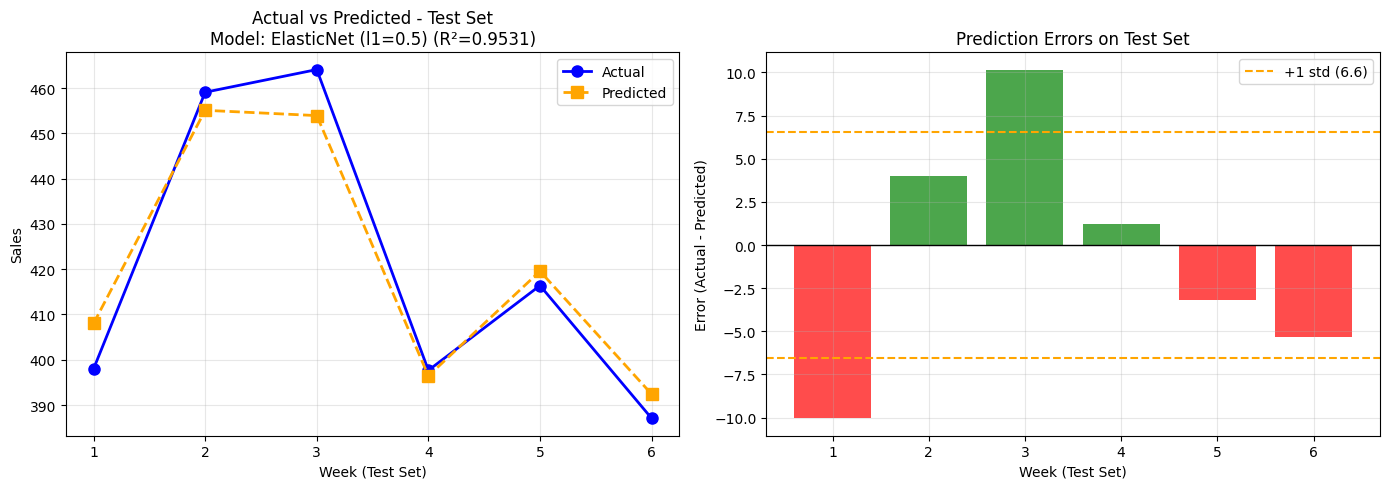

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Actual vs Predicted on Test Set
axes[0].plot(range(1, len(y_test)+1), y_test, 'o-', label='Actual', linewidth=2, markersize=8, color='blue')
axes[0].plot(range(1, len(y_test)+1), y_test_pred, 's--', label='Predicted', linewidth=2, markersize=8, color='orange')
axes[0].set_xlabel('Week (Test Set)')
axes[0].set_ylabel('Sales')
axes[0].set_title(f'Actual vs Predicted - Test Set\nModel: {best_name} (R²={test_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Error distribution
errors = y_test - y_test_pred
colors = ['red' if e < 0 else 'green' for e in errors]
axes[1].bar(range(1, len(errors)+1), errors, alpha=0.7, color=colors)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].axhline(y=errors.std(), color='orange', linestyle='--', label=f'+1 std ({errors.std():.1f})')
axes[1].axhline(y=-errors.std(), color='orange', linestyle='--')
axes[1].set_xlabel('Week (Test Set)')
axes[1].set_ylabel('Error (Actual - Predicted)')
axes[1].set_title('Prediction Errors on Test Set')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [132]:
# Save best model
joblib.dump(best_model, 'marketing_model_best.pkl')
print("Saved: marketing_model_best.pkl")

# Save model metadata
model_metadata = {
    'model_name': best_name,
    'test_r2': test_r2,
    'test_mape': test_mape,
    'train_r2': best_result['Train_R2'],
    'cv_r2_mean': best_result['CV_R2_mean'],
    'feature_count': len(feature_cols),
    'train_size': len(train_df),
    'test_size': len(test_df)
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("Saved: model_metadata.json")

# Save full comparison results
results_df.to_csv('model_comparison_results.csv', index=False)
print("Saved: model_comparison_results.csv")

print("\n" + "="*60)
print("MODULE 2 - COMPLETED")
print("="*60)
print(f"Best model: {best_name}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Features used: {len(feature_cols)}")
print(f"Train weeks: {len(train_df)}")
print(f"Test weeks: {len(test_df)}")

Saved: marketing_model_best.pkl
Saved: model_metadata.json
Saved: model_comparison_results.csv

MODULE 2 - COMPLETED
Best model: ElasticNet (l1=0.5)
Test R²: 0.9531
Test MAPE: 1.34%
Features used: 4
Train weeks: 54
Test weeks: 6


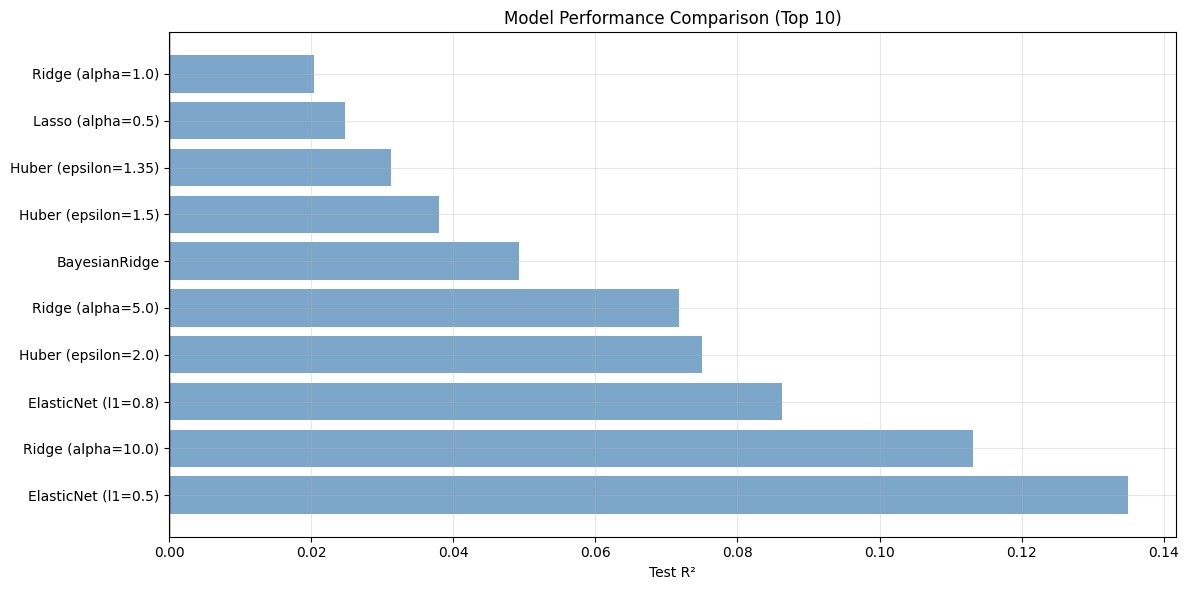

In [133]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(12, 6))

top_models = results_df.head(10)
x_pos = np.arange(len(top_models))
ax.barh(x_pos, top_models['Test_R2'].values, alpha=0.7, color='steelblue')
ax.set_yticks(x_pos)
ax.set_yticklabels(top_models['Model'].values)
ax.set_xlabel('Test R²')
ax.set_title('Model Performance Comparison (Top 10)')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()